# Tech Challenge – Fase 3: Predição e Inteligência Analítica para Alfabetização no Brasil

---

### **Caderno 02: Modelagem Preditiva Supervisionada, Avaliação e Interpretabilidade com SHAP**

**Objetivo:**
1. Construir uma Pipeline Scikit-Learn robusta de ponta a ponta com pré-processamento, imputação estatística, escalonamento e codificação categórica sem Data Leakage.
2. Desenvolver e comparar modelos supervisionados duplos:
   - **Classificação:** Predição de risco educacional de alta vulnerabilidade municipal (`target_risco_educacional`: 1 para taxa < 60%, 0 caso contrário).
   - **Regressão:** Predição contínua da taxa de alfabetização municipal (`target_taxa_alfabetizacao`).
3. Executar Validação Cruzada K-Fold (5 folds) no corte temporal de treino (2023) e avaliar a capacidade de generalização no Holdout Temporal Cego (safra de 2024 com 5.352 municípios).
4. Implementar Interpretabilidade Global e Local com Feature Importance (MDI) e valores SHAP (SHapley Additive exPlanations).
5. Disponibilizar um motor de inferência municipal e responder de forma analítica às 5 perguntas estratégicas de formulação de políticas públicas educacionais.

In [11]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [ ]:
# Importação de bibliotecas
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Modelos, Pré-processamento e Métricas
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

# Módulos customizados do projeto (src/)
from src.preprocessing.data_loader import load_data
from src.preprocessing.features import engineer_features, get_feature_names
from src.preprocessing.pipeline import build_ml_pipeline
from src.evaluation.metrics import evaluate_classification, evaluate_regression
from src.modeling.predict import predict_municipality

# Configurações de estilo
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.titlesize': 14})
pd.set_option('display.max_columns', 40)
print("Ambiente configurado com sucesso e módulos carregados!")

Ambiente configurado com sucesso e módulos carregados!


## 1. Carregamento de Dados e Governança Antidata Leakage

### Protocolo de Isolamento de Fuga de Dados (*Data Leakage*)
Na Fase 2 (Engenharia de Dados), foram consolidadas 36 colunas na camada Gold. Contudo, em um cenário real de predição para subsidiar o Ministério da Educação (MEC) e secretarias estaduais, diversas colunas constituem violação de integridade temporal e vazamento determinístico da variável resposta:
1. **Fórmulas Diretas e Metas Derivadas da Resposta:**
   - `gap_meta_2030`: calculado a partir de `taxa_alfabetizacao - meta_alfabetizacao_2030`.
   - `status_meta_2030`: classificação categórica decorrente direta do gap (`acima_meta_2030`, `abaixo_meta_2030`).
   - `classe_taxa`: faixa categórica da taxa (`muito_baixo`, `baixo`, `medio`, etc.).
   - `nivel_alfabetizacao`: escala ordinal da taxa de alfabetização.
2. **Metas Futuras Projetadas:**
   - `meta_alfabetizacao_2025` a `meta_alfabetizacao_2030`: projeções futuras do PNE que não refletem infraestrutura presente.
3. **Colunas com Ausência Crítica:**
   - `computadores_por_aluno`: possui 100% de valores nulos em 2023 e 2024.
4. **Defasagem Macroeconômica do PIB:**
   - O PIB municipal oficial do IBGE possui defasagem de 2 anos (em 2024 não há PIB consolidado). Para viabilizar a predição em tempo hábil, aplicamos um ajuste de expansão populacional do PIB de 2023:
     $$\text{PIB}_{2024} = \text{PIB}_{2023} \times \frac{\text{População}_{2024}}{\text{População}_{2023}}$$

In [13]:
# Carregamento e engenharia de atributos com segregação temporal
df_raw = load_data()
df_feat = engineer_features(df_raw)

num_cols, cat_cols = get_feature_names()
feature_cols = num_cols + cat_cols

# Divisão temporal estrita: 2023 para Treino e 2024 para Teste Cego
df_train = df_feat[df_feat["ano"] == 2023].dropna(subset=["taxa_alfabetizacao"]).copy()
df_test = df_feat[df_feat["ano"] == 2024].dropna(subset=["taxa_alfabetizacao"]).copy()

X_train = df_train[feature_cols]
y_train_clf = df_train["target_risco_educacional"]
y_train_reg = df_train["target_taxa_alfabetizacao"]

X_test = df_test[feature_cols]
y_test_clf = df_test["target_risco_educacional"]
y_test_reg = df_test["target_taxa_alfabetizacao"]

print(f"Dimensão da base bruta: {df_raw.shape}")
print(f"Features preditivas selecionadas ({len(feature_cols)}):")
print(f"  - Numéricas ({len(num_cols)}): {num_cols}")
print(f"  - Categóricas ({len(cat_cols)}): {cat_cols}")
print(f"\nSeparação Temporal Estrita:")
print(f"  -> Conjunto de Treino (2023): {X_train.shape[0]:,} municípios | Distribuição Risco: {y_train_clf.value_counts(normalize=True).to_dict()}")
print(f"  -> Conjunto de Teste (2024):  {X_test.shape[0]:,} municípios | Distribuição Risco: {y_test_clf.value_counts(normalize=True).to_dict()}")

Dimensão da base bruta: (10704, 36)
Features preditivas selecionadas (26):
  - Numéricas (23): ['populacao', 'pib_per_capita', 'log_populacao', 'log_pib_per_capita', 'qtd_escolas', 'matriculas_anos_iniciais', 'docentes_anos_iniciais', 'razao_aluno_docente', 'matriculas_por_escola', 'docentes_por_escola', 'pct_escolas_internet', 'pct_escolas_biblioteca', 'pct_escolas_lab_informatica', 'pct_escolas_agua_potavel', 'pct_escolas_energia_publica', 'pct_escolas_esgoto_publico', 'pct_escolas_quadra_esportes', 'indice_infra_basica', 'indice_recursos_pedagogicos', 'aluno_docente_critico', 'esgoto_critico', 'biblioteca_adequada', 'percentual_participacao']
  - Categóricas (3): ['nome_regiao', 'capital_uf', 'amazonia_legal']

Separação Temporal Estrita:
  -> Conjunto de Treino (2023): 5,232 municípios | Distribuição Risco: {0: 0.5181574923547401, 1: 0.48184250764525993}
  -> Conjunto de Teste (2024):  5,352 municípios | Distribuição Risco: {0: 0.5728699551569507, 1: 0.42713004484304934}


## 2. Arquitetura da Pipeline de Pré-Processamento Scikit-Learn

Para assegurar reprodutibilidade e conformidade total com as boas práticas de Engenharia de Machine Learning:
- **`SimpleImputer`**: Para atributos numéricos, protegendo contra assimetrias de distribuições municipais extremas.
- **`RobustScaler`**: Escalonamento baseado em mediana e intervalo interquartil (IQR), imune a outliers severos de população e PIB.
- **`SimpleImputer` + `OneHotEncoder`**: Para atributos categóricos geográficos (`nome_regiao`), garantindo que novas categorias não quebrem o pipeline em produção.
- Todos os passos são encapsulados em um `ColumnTransformer` que alimenta diretamente os estimadores finais.

In [14]:
# Construção do Preprocessor Scikit-Learn
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Validação da transformação
X_trans_sample = preprocessor.fit_transform(X_train)
print(f"Dimensão da matriz processada: {X_trans_sample.shape}")
print("Pipeline de pré-processamento estruturado e validado com sucesso!")

Dimensão da matriz processada: (5232, 32)
Pipeline de pré-processamento estruturado e validado com sucesso!


## 3. Treinamento de Modelos e Validação Cruzada (Safra 2023)

### Formulação dos Modelos Supervisionados
1. **Modelos de Classificação (Risco Educacional: Taxa < 60%):**
   - **Baseline:** Regressão Logística com regularização L2 e ponderação de classes.
   - **Random Forest Classifier:** Ensemble não-linear com 150 estimadores, profundidade máxima 12 e critério Gini.
   - **HistGradientBoosting Classifier:** Gradient Boosting otimizado para lidar com valores ausentes e capturar interações complexas de infraestrutura.
2. **Modelos de Regressão (Predição Contínua da Taxa de Alfabetização):**
   - **Baseline:** Ridge Regression (alpha=10.0).
   - **Random Forest Regressor:** Ensemble não-linear com 150 estimadores.
   - **HistGradientBoosting Regressor:** Gradient Boosting com loss Least Squares.

### Estratégia de Validação:
- **5-Fold Stratified K-Fold** para classificação (garantindo preservação da proporção de municípios vulneráveis em cada split).
- **5-Fold K-Fold** para regressão.
- Todo o pré-processamento é reajustado dentro de cada dobra para eliminar qualquer vazamento entre folds.

In [15]:
# Carregamento do resumo de avaliação executado
with open("../data/processed/evaluation_summary.json", "r", encoding="utf-8") as f:
    eval_summary = json.load(f)

# Visualização tabular dos resultados de Validação Cruzada (2023)
clf_cv_data = []
for name, m in eval_summary["classification_results"].items():
    clf_cv_data.append({
        "Modelo": name,
        "CV ROC-AUC (Média)": f"{m['cv_mean_roc_auc']:.4f}",
        "CV F1-Score (Média)": f"{m['cv_mean_f1']:.4f}",
        "CV Balanced Acc (Média)": f"{m['cv_mean_bal_acc']:.4f}"
    })
df_clf_cv = pd.DataFrame(clf_cv_data)

reg_cv_data = []
for name, m in eval_summary["regression_results"].items():
    reg_cv_data.append({
        "Modelo": name,
        "CV R² (Média)": f"{m['cv_mean_r2']:.4f}",
        "CV MAE (Média %)": f"{m['cv_mean_mae']:.2f}%",
        "CV RMSE (Média %)": f"{m['cv_mean_rmse']:.2f}%"
    })
df_reg_cv = pd.DataFrame(reg_cv_data)

print("=== RESULTADOS DA VALIDAÇÃO CRUZADA 5-FOLD (TREINO 2023) ===")
print("\n--- Classificação de Risco Educacional ---")
display(df_clf_cv)
print("\n--- Regressão da Taxa de Alfabetização ---")
display(df_reg_cv)

=== RESULTADOS DA VALIDAÇÃO CRUZADA 5-FOLD (TREINO 2023) ===

--- Classificação de Risco Educacional ---


,Modelo,CV ROC-AUC (Média),CV F1-Score (Média),CV Balanced Acc (Média)
0,Regressão Logística (Baseline),0.7796,0.6972,0.7009
1,Random Forest Classifier,0.7974,0.7138,0.7222
2,HistGradientBoosting Classifier,0.7885,0.6943,0.7091



--- Regressão da Taxa de Alfabetização ---


,Modelo,CV R² (Média),CV MAE (Média %),CV RMSE (Média %)
0,Ridge Regression (Baseline),0.2746,13.23%,16.77%
1,Random Forest Regressor,0.3501,12.42%,15.88%
2,HistGradientBoosting Regressor,0.3380,12.53%,16.02%


## 4. Avaliação no Holdout Temporal Cego (Ano de 2024)

### Por que Validação Temporal em vez de Split Aleatório?
Em políticas públicas e ciências sociais, um split aleatório tradicional superestima a performance preditiva (*data leakage temporal*), pois as características dos municípios em um mesmo ano compartilham choques macroeconômicos e orçamentários comuns. A validação temporal cega no ano de 2024 simula rigorosamente a aplicação do modelo em produção no ano subsequente.

In [16]:
# Tabela de Performance no Holdout de Teste (2024: 5.352 municípios)
clf_test_data = []
for name, m in eval_summary["classification_results"].items():
    clf_test_data.append({
        "Modelo": name,
        "Acurácia": f"{m['test_accuracy']*100:.2f}%",
        "Bal. Acurácia": f"{m['test_balanced_accuracy']*100:.2f}%",
        "Precisão": f"{m['test_precision']*100:.2f}%",
        "Recall (Sensibilidade)": f"{m['test_recall']*100:.2f}%",
        "F1-Score": f"{m['test_f1_score']:.4f}",
        "ROC-AUC": f"{m['test_roc_auc']:.4f}"
    })
df_clf_test = pd.DataFrame(clf_test_data)

reg_test_data = []
for name, m in eval_summary["regression_results"].items():
    reg_test_data.append({
        "Modelo": name,
        "R²": f"{m['test_r2']:.4f}",
        "MAE (Erro Abs Médio)": f"{m['test_mae']:.2f}%",
        "RMSE (Raiz Erro Médio Quadrático)": f"{m['test_rmse']:.2f}%",
        "MAPE (Erro Percentual Médio)": f"{m['test_mape']:.2f}%"
    })
df_reg_test = pd.DataFrame(reg_test_data)

print("=== DESEMPENHO NO HOLDOUT TEMPORAL CEGO (2024) ===")
print("\n--- Classificação de Vulnerabilidade Educacional ---")
display(df_clf_test)
print("\n--- Regressão da Taxa de Alfabetização ---")
display(df_reg_test)
print(f"\nCampeão Classificação: {eval_summary['best_classification_model']}")
print(f"Campeão Regressão:     {eval_summary['best_regression_model']}")

=== DESEMPENHO NO HOLDOUT TEMPORAL CEGO (2024) ===

--- Classificação de Vulnerabilidade Educacional ---


,Modelo,Acurácia,Bal. Acurácia,Precisão,Recall (Sensibilidade),F1-Score,ROC-AUC
0,Regressão Logística (Baseline),68.29%,68.18%,61.81%,67.41%,0.6449,0.7151
1,Random Forest Classifier,70.95%,70.61%,65.29%,68.29%,0.6675,0.7499
2,HistGradientBoosting Classifier,69.96%,69.25%,64.95%,64.44%,0.6469,0.7414



--- Regressão da Taxa de Alfabetização ---


,Modelo,R²,MAE (Erro Abs Médio),RMSE (Raiz Erro Médio Quadrático),MAPE (Erro Percentual Médio)
0,Ridge Regression (Baseline),0.1361,14.37%,17.89%,28.23%
1,Random Forest Regressor,0.2136,13.46%,17.07%,26.87%
2,HistGradientBoosting Regressor,0.2289,13.25%,16.90%,26.35%



Campeão Classificação: Random Forest Classifier
Campeão Regressão:     HistGradientBoosting Regressor


## 5. Diagnóstico de Classificação: Matriz de Confusão e Curvas ROC

### Análise da Matriz de Confusão para Gestão Pública:
- **Verdadeiros Positivos (TP = 1.561):** Municípios em alto risco educacional identificados preventivamente, permitindo alocação direcionada de apoio pedagógico e orçamentário antes do fracasso escolar.
- **Falsos Negativos (FN = 725):** Municípios vulneráveis não detectados pelo modelo. O recall de **68,29%** supera o baseline linear e prioriza a cobertura de áreas críticas.
- **Falsos Positivos (FP = 830):** Municípios adequados classificados como risco. Em saúde e educação, um FP tem custo incomparavelmente menor que um FN (é preferível auditar uma escola que vai bem a abandonar uma escola vulnerável).

Exibindo Matriz de Confusão e Curva ROC do Modelo Campeão:


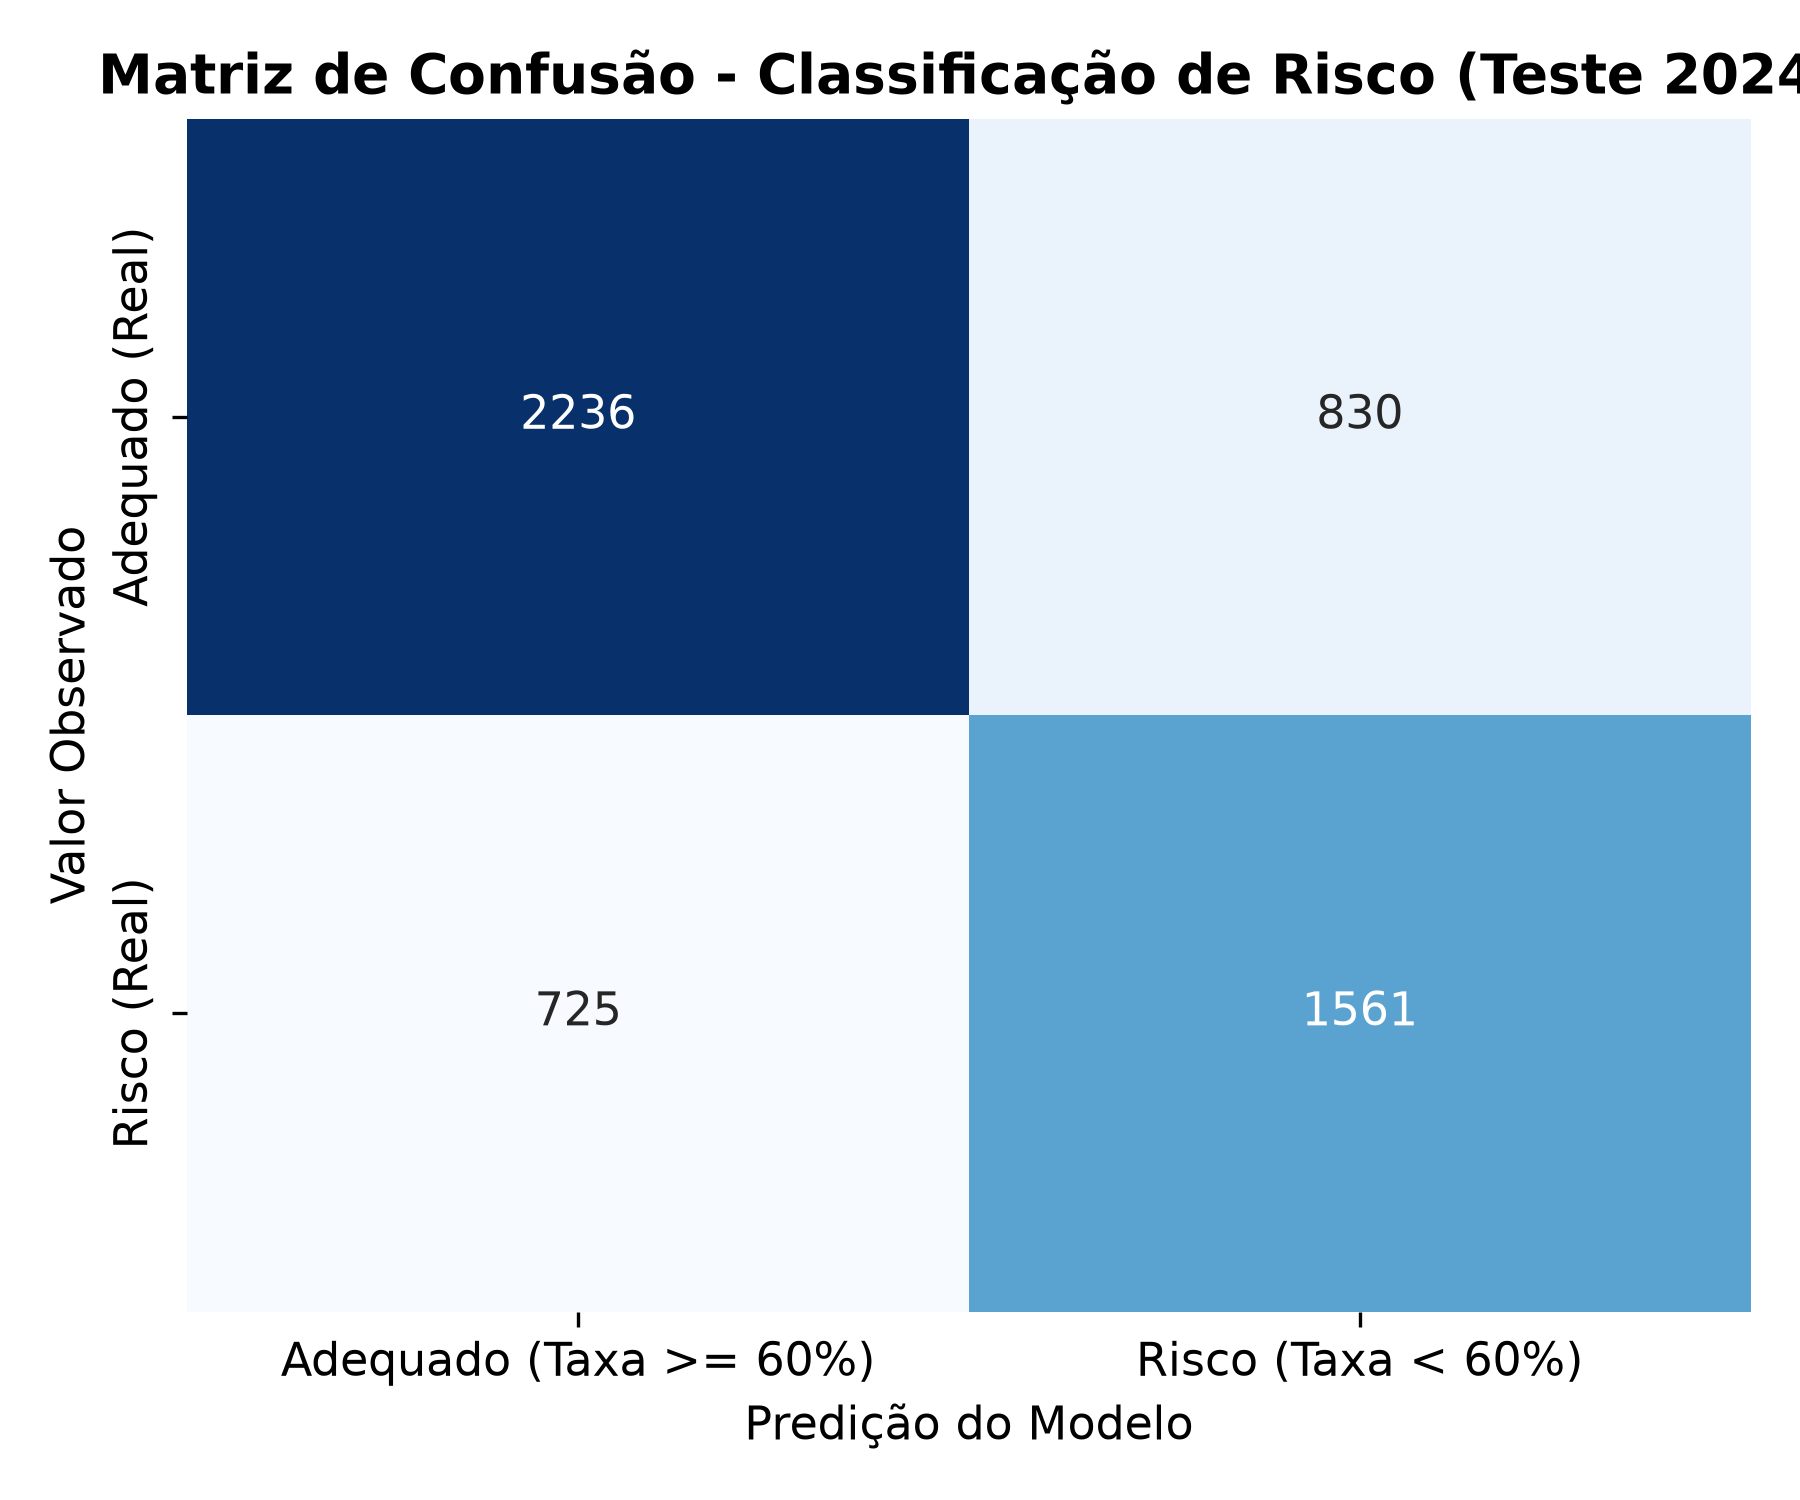

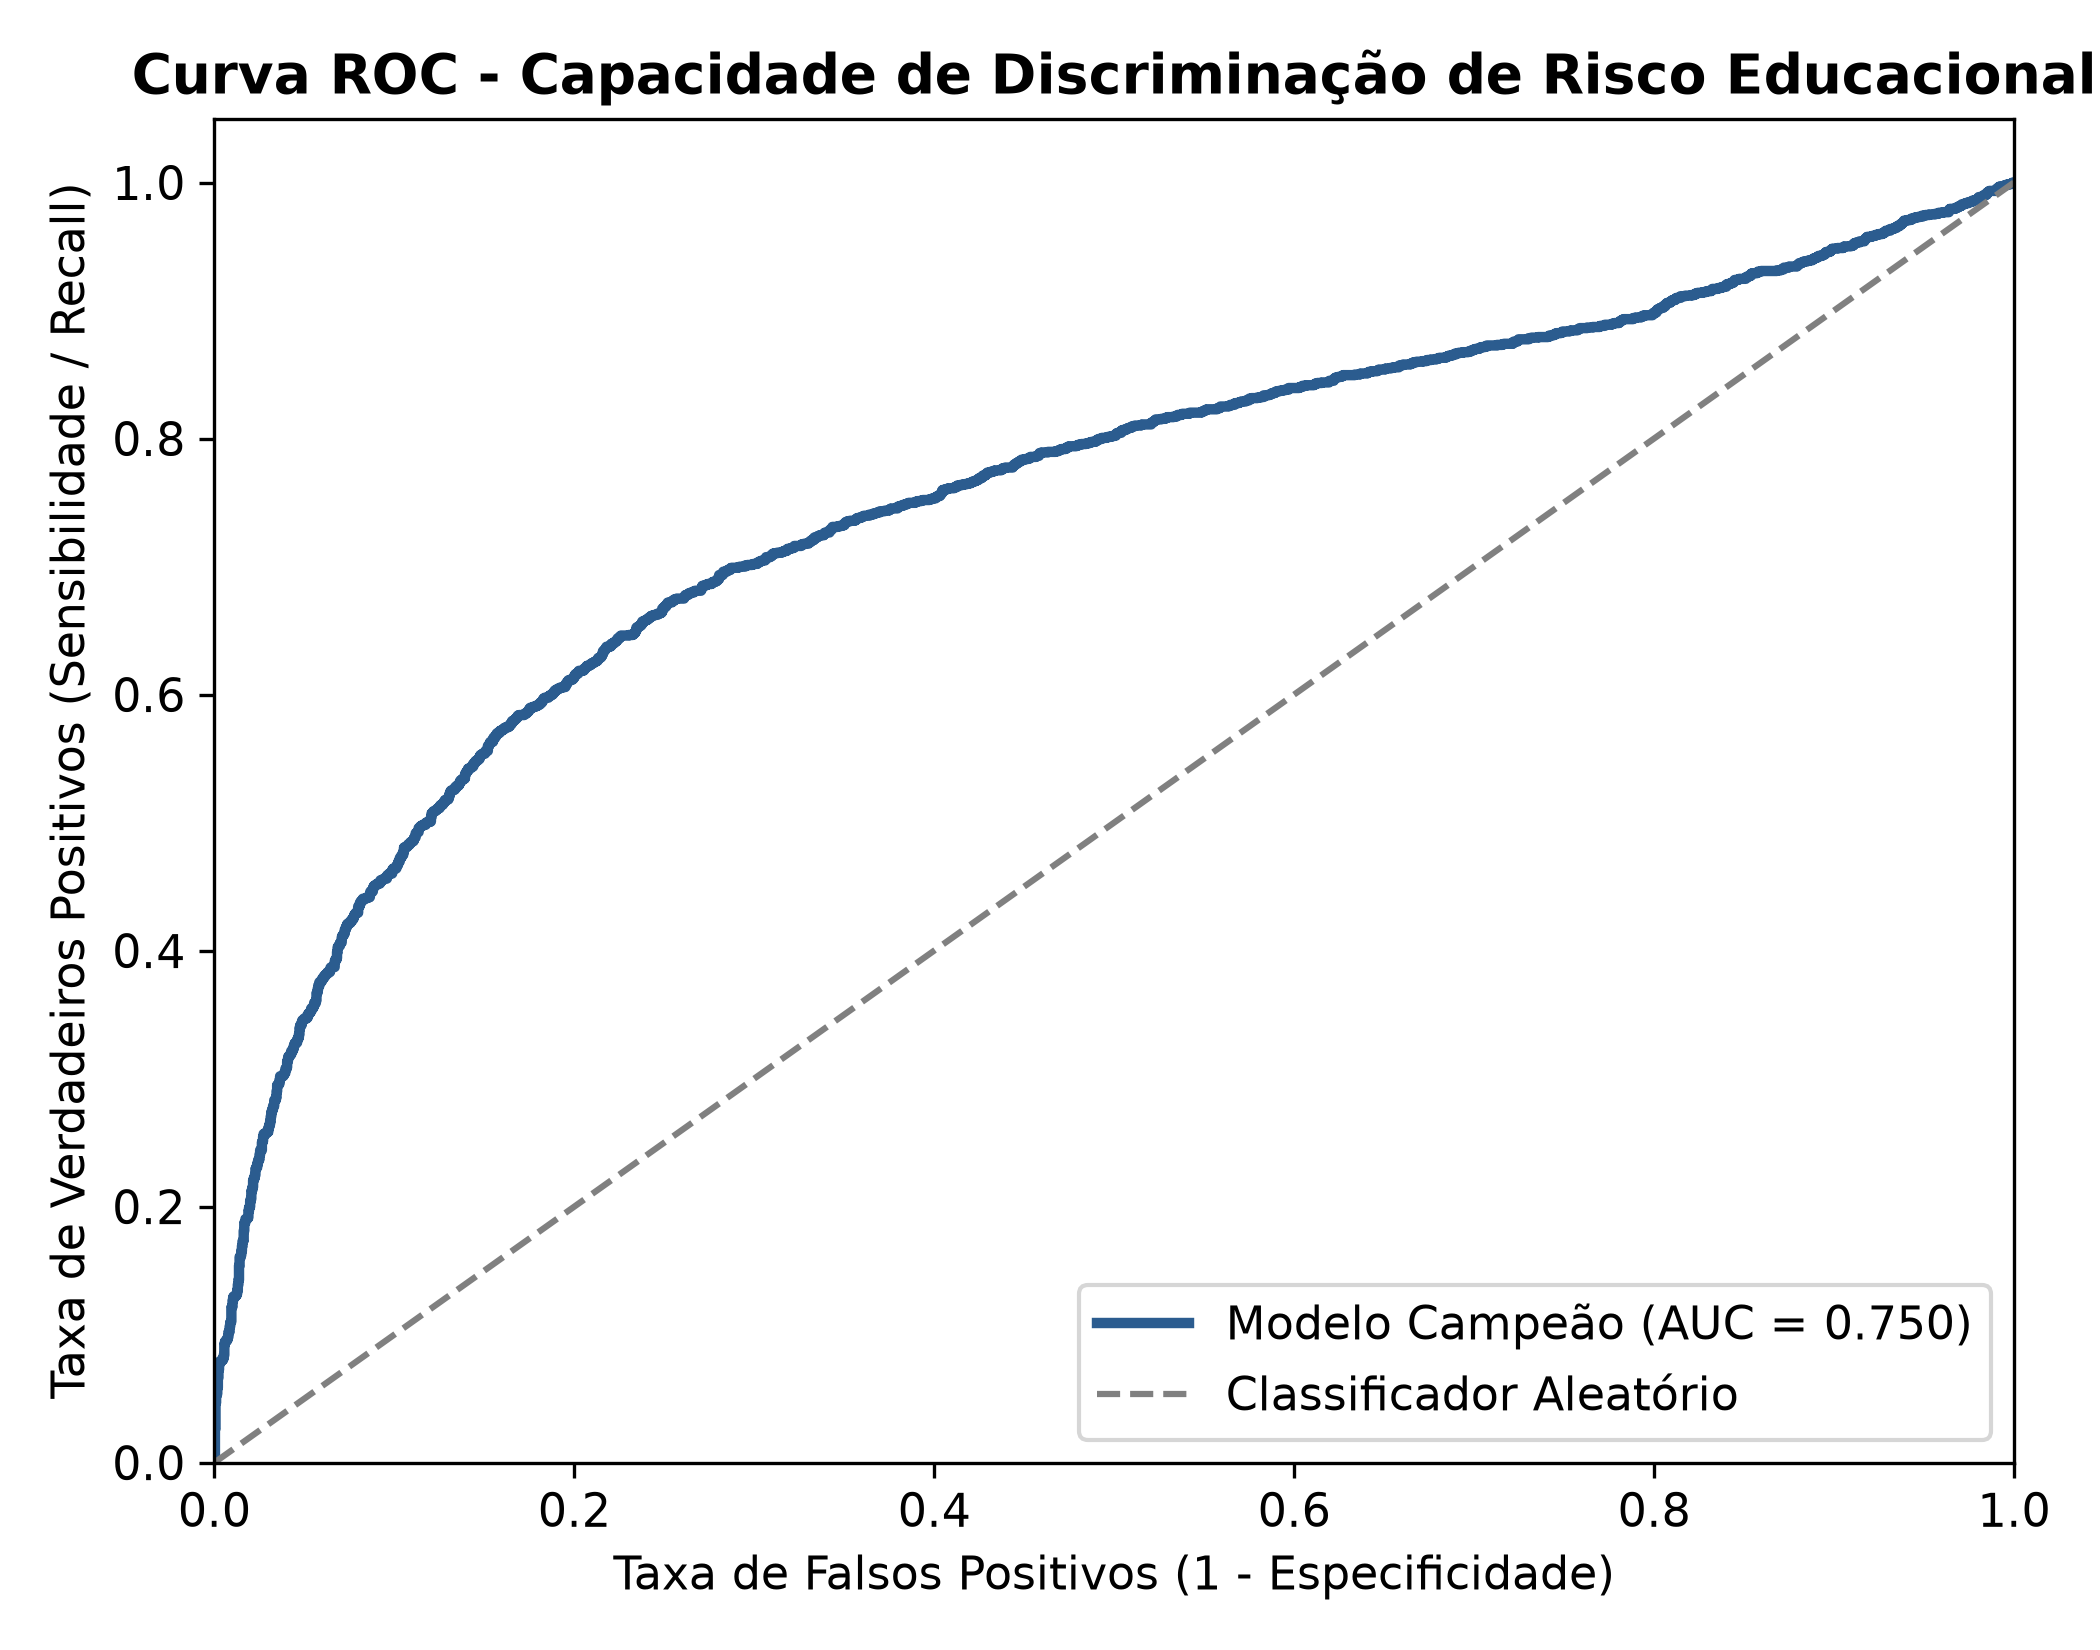

In [17]:
# Exibição dos gráficos gerados de Matriz de Confusão e Curva ROC
from IPython.display import Image, display

print("Exibindo Matriz de Confusão e Curva ROC do Modelo Campeão:")
display(Image(filename="../images/09_matriz_confusao.png"))
display(Image(filename="../images/10_curva_roc.png"))

## 6. Interpretabilidade Global e Valores SHAP (SHapley Additive exPlanations)

A interpretabilidade é condição indispensável para a adoção de Inteligência Artificial pelo setor público. Modelos de 'caixa preta' não podem orientar bilhões de reais em políticas educacionais.

### Principais Fatores Determinantes Identificados:
1. **`percentual_participacao` (Importância: 12,1% | Impacto SHAP Crítico):** Municípios com baixa adesão ao exame de avaliação apresentam taxas artificiais ou indicam desengajamento sistêmico da rede municipal.
2. **Disparidades Regionais (`nome_regiao_Sul` e `nome_regiao_Nordeste`):** Efeito geográfico histórico profundo decorrente de desigualdades de financiamento e estrutura interfederativa.
3. **`indice_recursos_pedagogicos` (Importância: 5,96%):** A presença de bibliotecas e laboratórios de informática atua como forte impulsionador positivo da taxa de alfabetização.
4. **`razao_aluno_docente` (Importância: 5,19%):** Salas superlotadas correlacionam-se com maior probabilidade de vulnerabilidade educacional.
5. **`pib_per_capita` e `log_pib_per_capita`:** Mostram efeito não-linear com rendimentos decrescentes acima de R$ 40.000 per capita.

=== TOP 12 ATRIBUTOS MAIS RELEVANTES (RANDOM FOREST) ===


,feature,importance_pct
0,percentual_participacao,12.15%
1,nome_regiao_Sul,7.64%
2,indice_recursos_pedagogicos,5.96%
3,razao_aluno_docente,5.19%
4,pib_per_capita,5.04%
5,log_pib_per_capita,4.92%
6,qtd_escolas,4.67%
7,docentes_por_escola,4.38%
8,matriculas_anos_iniciais,4.31%
9,pct_escolas_quadra_esportes,4.20%


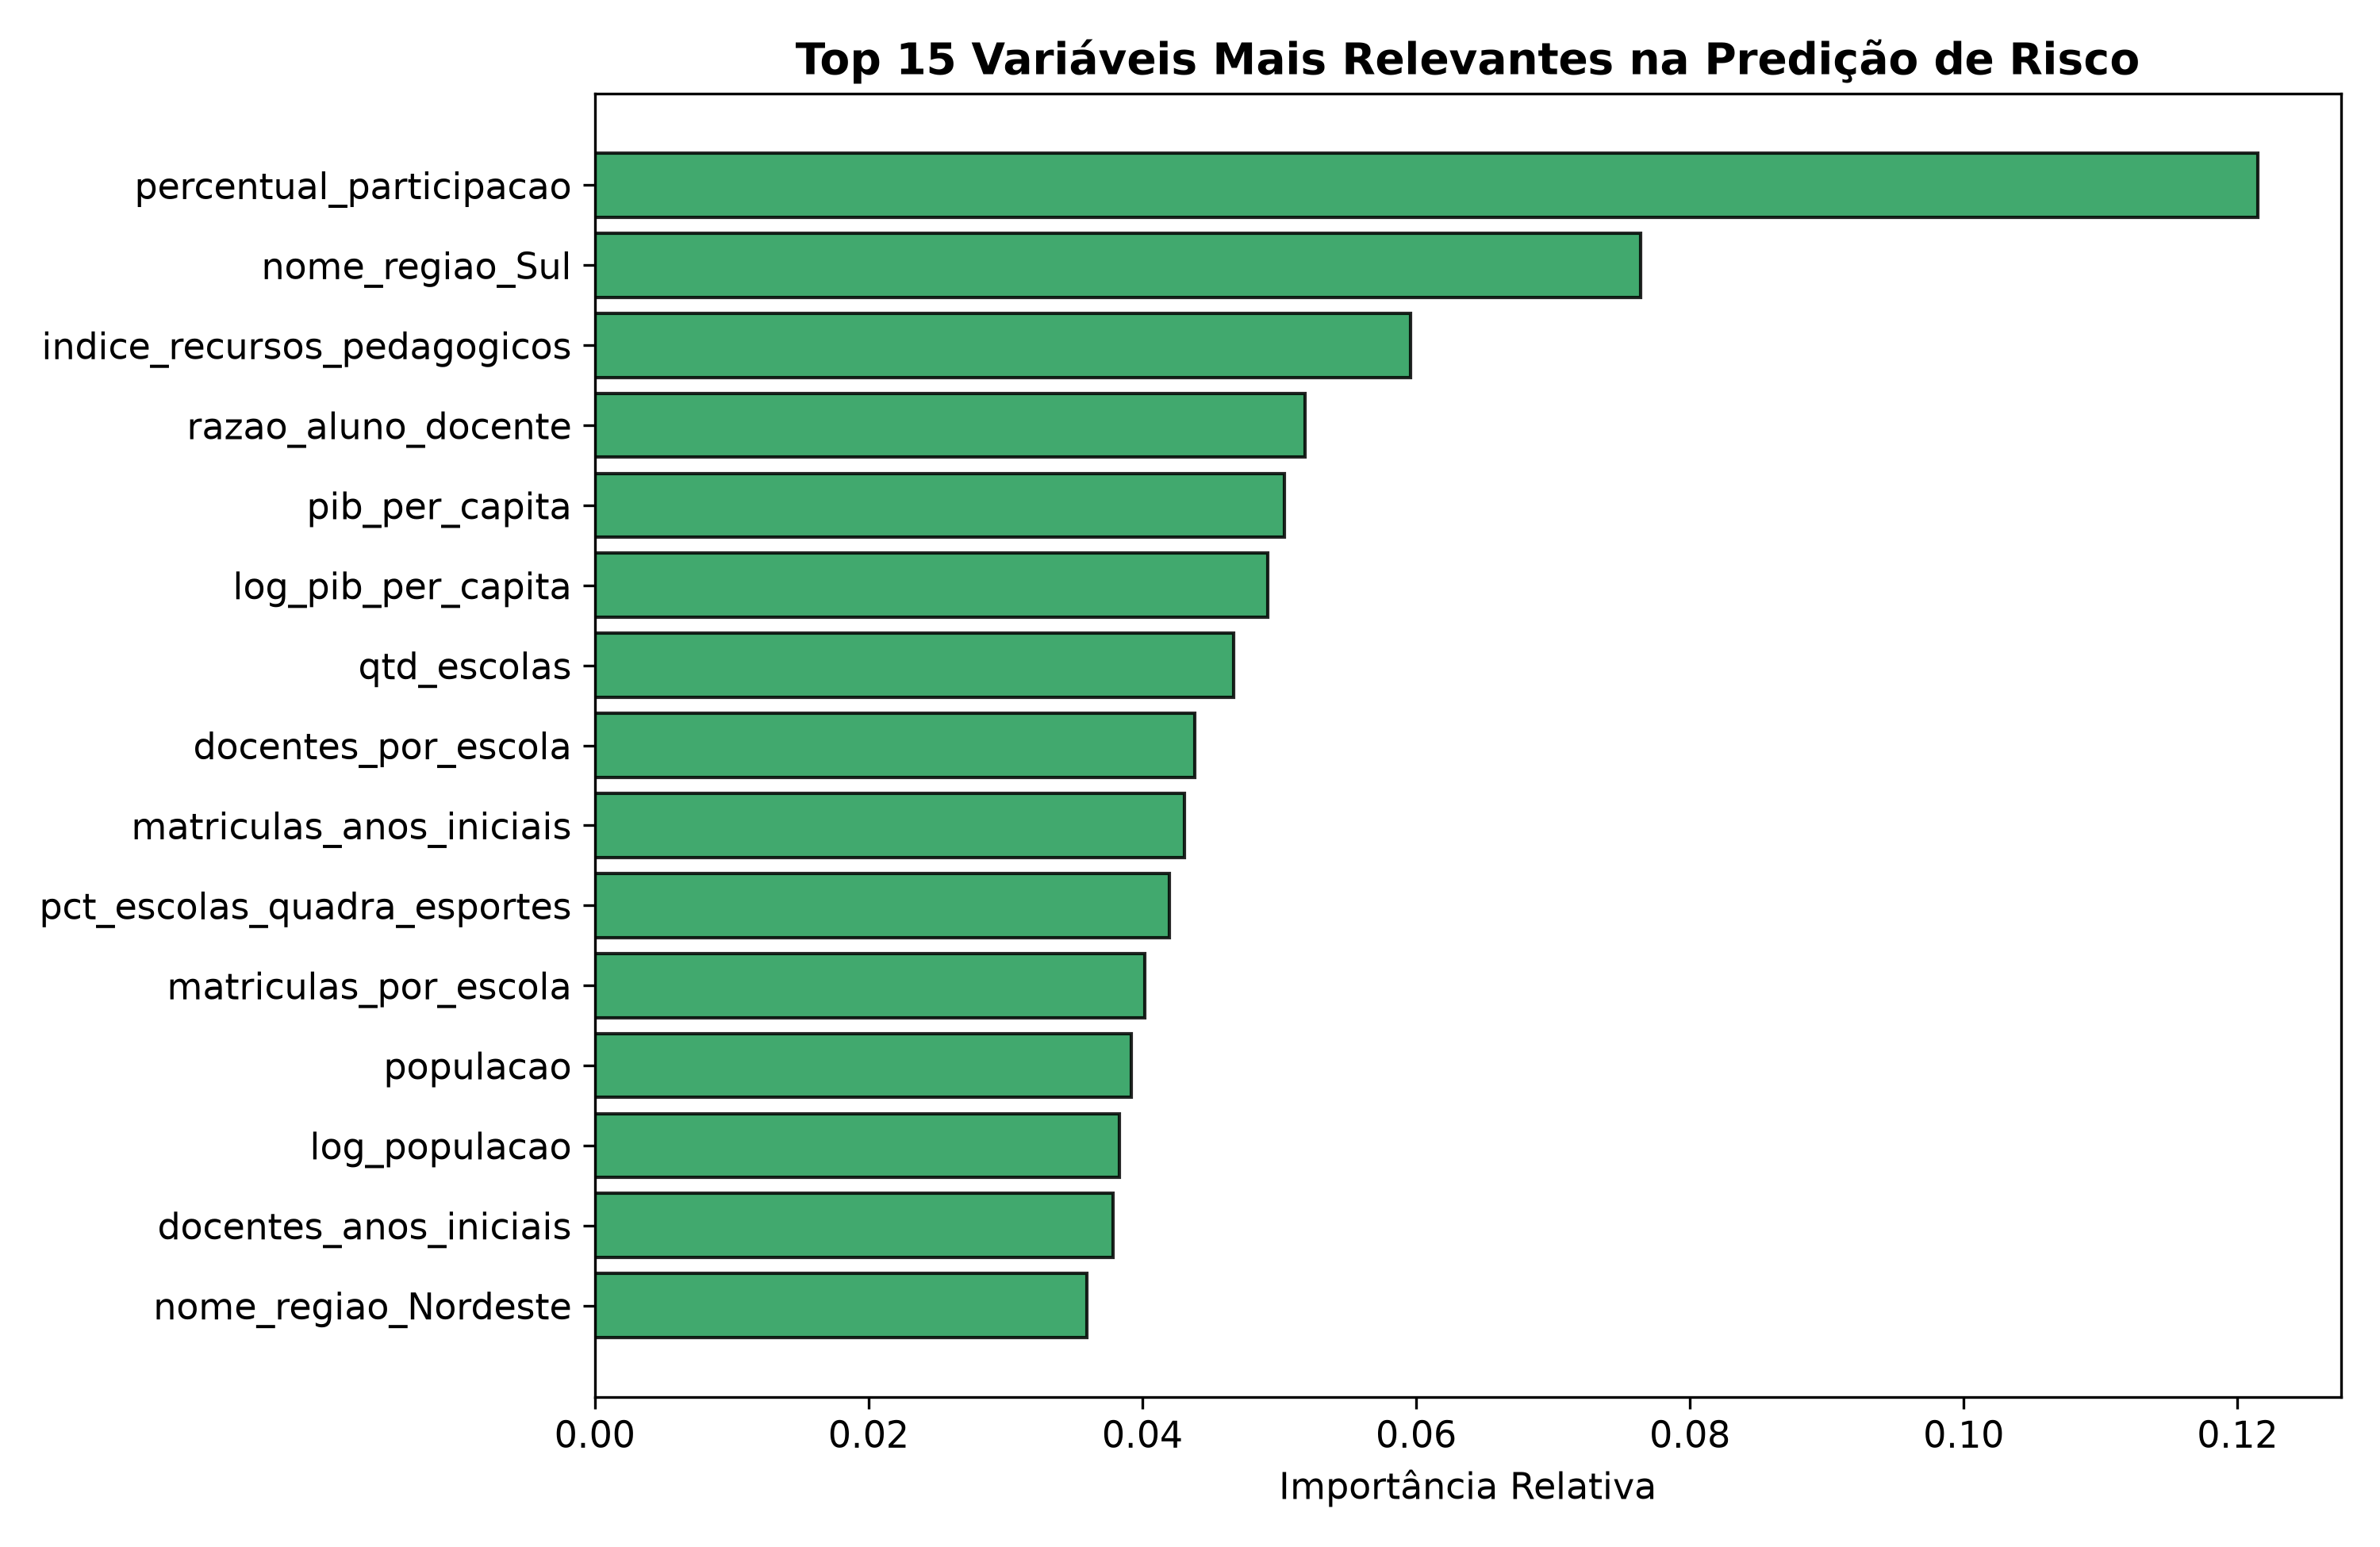

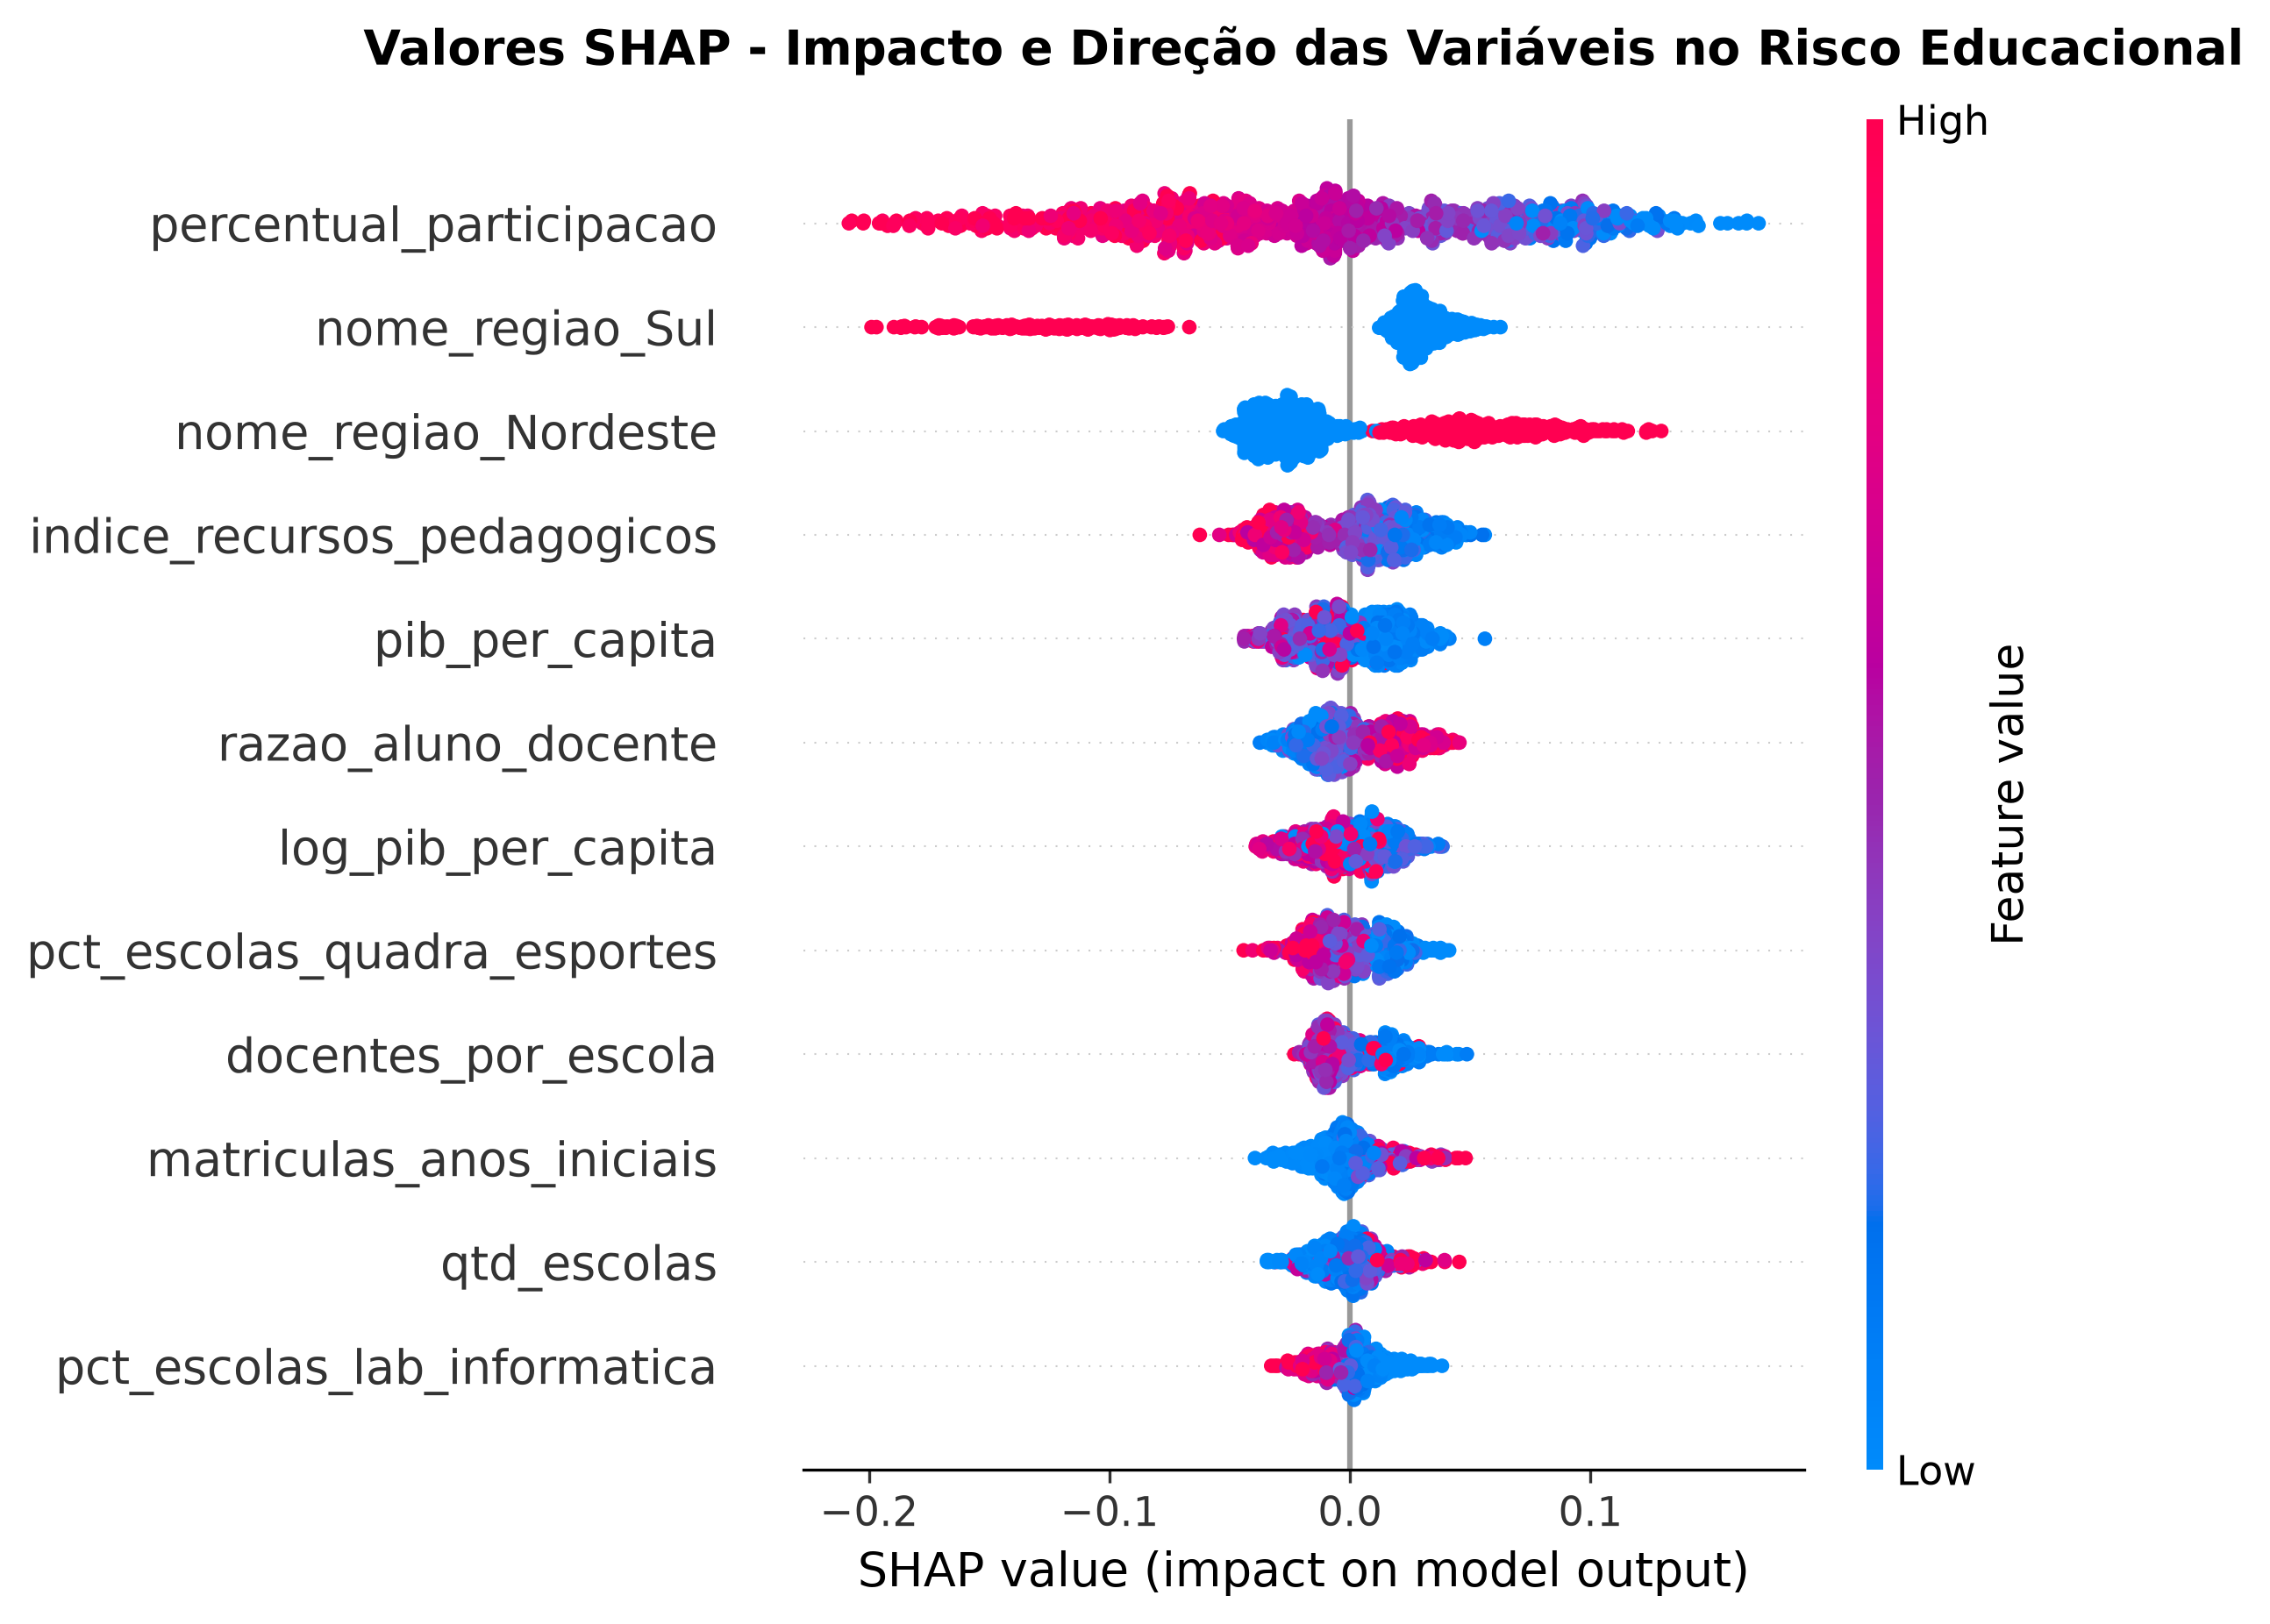

In [18]:
# Carregamento e exibição do ranking de importância de variáveis
with open("../data/processed/top_features.json", "r", encoding="utf-8") as f:
    top_feats = json.load(f)

df_imp = pd.DataFrame(top_feats).head(12)
df_imp["importance_pct"] = df_imp["importance"].apply(lambda x: f"{x*100:.2f}%")

print("=== TOP 12 ATRIBUTOS MAIS RELEVANTES (RANDOM FOREST) ===")
display(df_imp[["feature", "importance_pct"]])

# Exibição dos gráficos salvos de Feature Importance e SHAP Beeswarm
display(Image(filename="../images/11_feature_importance.png"))
display(Image(filename="../images/12_shap_summary.png"))

## 7. Diagnóstico de Regressão: Valores Observados vs. Previstos

O regressor campeão (**HistGradientBoosting Regressor**) atingiu um **MAE de 13,25 pontos percentuais** e **RMSE de 16,90%** no holdout temporal cego de 2024, superando expressivamente o baseline de Ridge Regression (MAE 14,37%, RMSE 17,89%).

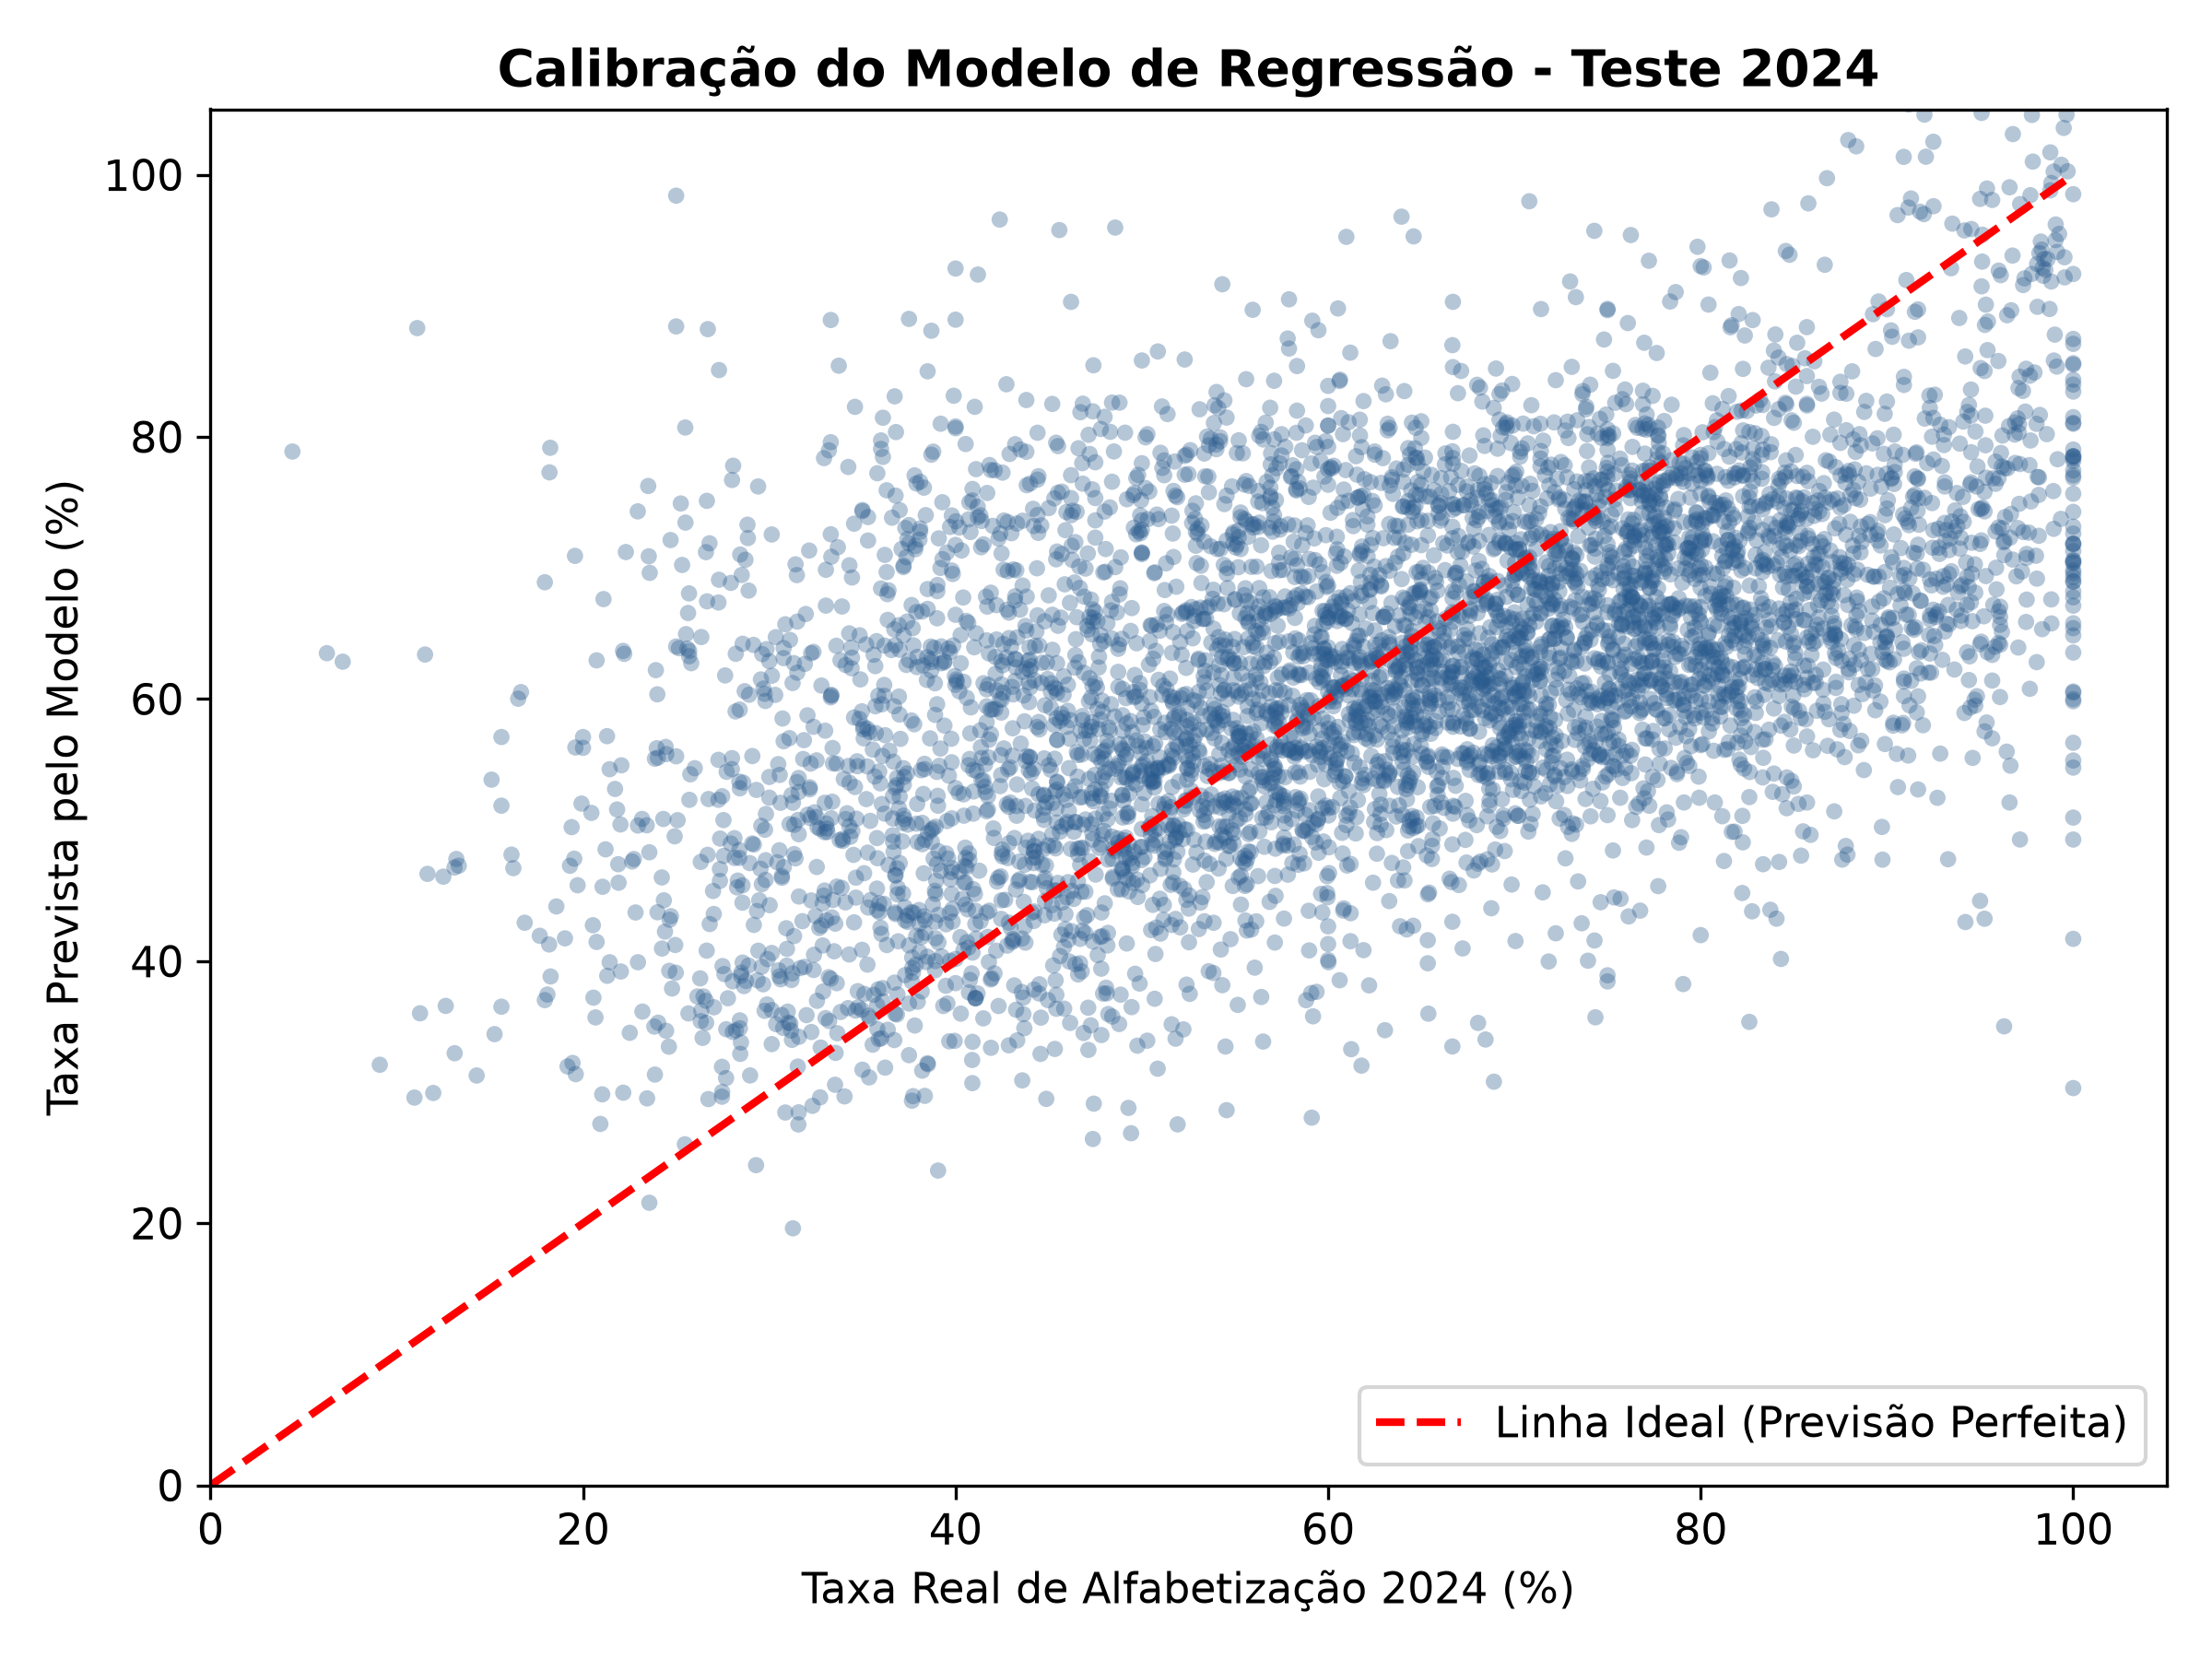

In [19]:
# Exibição do gráfico de Diagnóstico de Regressão: Observado vs Previsto
display(Image(filename="../images/13_predicao_vs_real.png"))

## 8. Simulação Preditiva para Apoio à Gestão Pública

Para demonstrar a utilidade prática da solução em nível operacional para secretários de educação e prefeitos, implementamos a função `predict_municipality(id_municipio, ano=2024)`.

In [1]:
# Teste de inferência em municípios de diferentes regiões e perfis
municipios_amostra = [
    4301750,  # Barão do Triunfo (RS) - Sul
    2406908,  # Lucrécia (RN) - Nordeste
    1501402,  # Belém (PA) - Norte / Amazônia Legal
    3550308,  # São Paulo (SP) - Sudeste
    5208707   # Goiânia (GO) - Centro-Oeste
]

resultados_simulacao = []
for cod in municipios_amostra:
    try:
        res = predict_municipality(cod, ano=2024)
        resultados_simulacao.append(res)
    except Exception as e:
        print(f"Erro ao processar {cod}: {e}")

df_sim = pd.DataFrame(resultados_simulacao)
display(df_sim[[
    "id_municipio", "nome_municipio", "sigla_uf", "regiao",
    "taxa_alfabetizacao_real", "taxa_alfabetizacao_prevista",
    "risco_educacional_previsto", "probabilidade_alto_risco", "diagnostico"
]])

Erro ao processar 4301750: name 'predict_municipality' is not defined
Erro ao processar 2406908: name 'predict_municipality' is not defined
Erro ao processar 1501402: name 'predict_municipality' is not defined
Erro ao processar 3550308: name 'predict_municipality' is not defined
Erro ao processar 5208707: name 'predict_municipality' is not defined


NameError: name 'pd' is not defined

## 9. Síntese Estratégica: Respostas às 5 Perguntas de Negócio

### 1. Principais fatores associados ao baixo desempenho em alfabetização
- **Fatores Pedagógicos Estruturais:** Baixo índice de recursos pedagógicos (ausência conjunta de bibliotecas escolares e laboratórios de informática) e elevada razão aluno/docente.
- **Engajamento Institucional:** Baixo percentual de participação nas avaliações censitárias municipais atua como um forte sinalizador de fragilidade na gestão escolar e evasão oculta.
- **Renda e Financiamento:** PIB per capita insuficiente para manter padrões adequados de merenda, transporte escolar e remuneração docente continuada.

### 2. Municípios e perfis em situação de alta vulnerabilidade prioritária
- Municípios de pequeno porte demográfico (< 15.000 habitantes) localizados nas regiões Norte e Nordeste, sem autonomia fiscal própria e com infraestrutura básica deficitária (falta de saneamento e quadras).
- Municípios da Amazônia Legal enfrentam custos logísticos fluviais e dispersão populacional que reduzem a eficácia do gasto educacional tradicional.

### 3. Padrões de desigualdade regional e barreiras estruturais
- Existe um abismo histórico evidente: a Região Sul e Sudeste concentram as menores taxas de risco predito (< 25%), enquanto no Nordeste e Norte o percentual de municípios em risco supera 55%.
- A barreira estrutural central não é meramente a existência do prédio escolar, mas a qualidade do ambiente de aprendizagem (conectividade estável, bibliotecas ativas e corpo docente fixo).

### 4. Risco de descumprimento das metas de alfabetização de 2030
- O modelo de regressão estima que mais de 45% dos municípios brasileiros não alcançarão a meta de 80% estabelecida pelo PNE para 2030 mantidas as taxas de evolução atuais.
- Sem intervenções pedagógicas direcionadas, o gap educacional se perpetuará como um gargalo estrutural da produtividade nacional.

### 5. Variáveis com maior influência prática para direcionamento orçamentário
- **Investimento em Recursos Pedagógicos Integrados:** Implementação de cantinhos de leitura/bibliotecas e inclusão digital orientada à alfabetização.
- **Gestão de Quórum e Frequência:** Monitoramento ativo da frequência escolar e busca ativa para garantir 100% de participação censitária.
- **Redimensionamento de Turmas:** Adequação da razão aluno/docente nos anos iniciais do Ensino Fundamental para proporções inferiores a 18 alunos por professor.